# PD Model

**Probability of default PD**

Probability of default is the likelihood that a borrower will fail to repay the loan (credit card, mortgage or non-mortgage loan) over a one-year period

**Contents**
- Build PD model with Logistic regression
- Model evaluation: Accuracy, AUROC, Gini, KS
- Decision making: From PD to Scorecard 
- Set Cutoffs

**Detail contents**

**I. Build PD model with Logistic regression**
- Remove the reference categories (only neeed n-1 dummies for n categories)

- Build LogReg model with p-values

 + Check statistically significant of coef. of dummy variables (p<alpha here p< 0.05 is good)
We only remove a variable Xi if all dummy variables are not sta. sign.  (meaning that if only one dummy variable of the original Xi is significant, we will keep that original variable Xi or keep all other dummies of that original variable)

+ Fit LogReg again

+ Interpretation: higher coef = lower PD (greater odds of being good borrower)

**II. Model evaluation: Accuracy, AUROC, Gini, KS**

In this notebook we consider:

+ Accuracy (not a good metric since data is imblanced: proportion of default customer is much smaller than non-default customer)

+ AUROC: area under ROC curve. Fair: 70 -80%, Good: 80-90%, Excellent: >90%

+ Gini: measure inequality between good and bad borrowers

+ KS: max distance between cdf of good and bad customers

We can also consider others: 

+ Lift: Assess the relative performance of the model at a different cut-off points.

+ Hosmer Lemeshow Test : Test to determine if the model is well calibrated to the actual risk in the portfolio.
(The null hypothesis for the test is that the distributions are the same. The test outputs a P-value that is rejected if it is below a specified level of significance.
)

**III. Decision making: From PD to Scorecard**

+ It is a requirement imposed by the Basel Accord.

+ The score range of FICO is from 300 to 850. We will normalize the coefficient of regression result to get the score in that given range.

**IV. Set Cutoffs**

+ Cut-off point is the minimum thresold score to decide whether to accept or reject loans. 

+ Borrowers with a credit score higher than the set cut-off point will be accepted for loans and those less than the cutoff point will be rejected.

# Data Preparation

In [1]:
import numpy as np
import pandas as pd

# for regression model
from sklearn.linear_model import LogisticRegression
from sklearn import metrics  
from sklearn.metrics import roc_curve, roc_auc_score

# for plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import pickle

# import os
# print(os.getcwd())
# os.chdir("C:/Users/Admin/..")
# print(os.getcwd())  # check current directory

# export user-defined functions
%run Userdefined_functions.ipynb

## Test and Train Dataset 

In [2]:
#loading csv files as pd dataframes
# FOLDER_NAME  = "C:/Users/Admin/..."

# inputs_train = pd.read_csv (FOLDER_NAME +'loan_data_inputs_train.csv',index_col =0).copy()

inputs_train = pd.read_csv ('loan_data_inputs_train.csv',index_col =0).copy()
targets_train = pd.read_csv ('loan_data_targets_train.csv',index_col =0).copy()
inputs_test = pd.read_csv ('loan_data_inputs_test.csv',index_col =0).copy()
targets_test = pd.read_csv ('loan_data_targets_test.csv',index_col =0).copy()

In [3]:
targets_train.value_counts()

good_bad
1           332250
0            40778
dtype: int64

In [4]:
inputs_train.shape

(373028, 313)

In [5]:
inputs_train.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [6]:
targets_test.value_counts()

good_bad
1           83067
0           10190
dtype: int64

In [7]:
inputs_test.shape

(93257, 313)

In [8]:
inputs_test.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

# I. PD Model Estimation

## Select features

For each feature, dummy variables were listed in columns. For example, for grades, we have 7 columns for Grades from Grade:A to Grade:G. Each column consists of values 1 or 0.  

eg. for Grades=A, we use 0 Non and 1 True (Grade A)  
We only need 7 - 1 columns in our prediction model. 

In this case, the reference category is Grade:D (see the first notebook).

**We have to remove one dummy column for each original variable**

In [9]:
# Here we select a limited set of input variables                                           
features = ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>=86',
]

In [10]:
# Here we store the names of the reference category dummy variables in a list.
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [11]:
# loading values of df in a new dataframe.   
inputs_train_ref_categories = inputs_train.loc[: ,features]
# drop the variables with variable names in the list with reference categories
inputs_train_ref_categories = inputs_train_ref_categories.drop(ref_categories, axis = 1)
 
inputs_train_ref_categories.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
427211,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
206088,0,0,1,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
136020,1,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
412305,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
36159,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0


### Build a Logistic Regression Model with P-Values

Logistic regression is considered for the PD model due to the Basel accord.

A p-value of 0.05 or lower is generally considered statistically significant.

Check p-values of all categories: if all dummy categories of a feature are above 0.05, eliminate them 

## Model fit

In [12]:
# Creating an instance from 'LogisticRegression_with_p_values()' class.
reg = LogisticRegression_with_p_values()

In [13]:
# Fitting and obtaining coefs 
reg.fit(inputs_train_ref_categories, targets_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
# creating a summary table
feature_name = inputs_train_ref_categories.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
# We take the result of the newly added method 'p_values'
p_values = reg.p_values
# Adding the intercept for completeness. We add the value 'NaN' in the beginning of the variable with p-values.
p_values = np.append(np.nan, np.array(p_values))
# Adding a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table['p_values'] = p_values

summary_table

,Feature name,Coefficients,p_values
0,Intercept,-1.163606,NaN
1,grade:A,0.475994,5.523277e-08
2,grade:B,0.546026,1.637573e-20
3,grade:C,0.497137,2.084614e-19
4,grade:D,0.423286,1.489520e-15
...,...,...,...
93,mths_since_last_record:3-20,0.925478,1.622434e-13
94,mths_since_last_record:21-31,0.886165,1.323561e-14
95,mths_since_last_record:32-80,1.074732,3.401828e-34
96,mths_since_last_record:81-86,0.690261,3.938938e-11


Based on the table, the following variables do not have much statistical significance:

* mths_since_earliest_cr_line
* delinq_2yrs
* open_acc
* total_acc
* mths_since_last_delinq
* mths_since_last_record

## Model fit after removing some features which are not statistically significant

In [15]:
# We are going to remove some features, the coefficients for all or almost all of the dummy variables for which,
# are not tatistically significant.

# We do that by putting them in the comment
# Variables

features = ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
#'mths_since_earliest_cr_line:<140',
#'mths_since_earliest_cr_line:141-164',
#'mths_since_earliest_cr_line:165-247',
#'mths_since_earliest_cr_line:248-270',
#'mths_since_earliest_cr_line:271-352',
#'mths_since_earliest_cr_line:>352',
#'delinq_2yrs:0',
#'delinq_2yrs:1-3',
#'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
#'open_acc:0',
#'open_acc:1-3',
#'open_acc:4-12',
#'open_acc:13-17',
#'open_acc:18-22',
#'open_acc:23-25',
#'open_acc:26-30',
#'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
#'total_acc:<=27',
#'total_acc:28-51',
#'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
#'mths_since_last_delinq:Missing',
#'mths_since_last_delinq:0-3',
#'mths_since_last_delinq:4-30',
#'mths_since_last_delinq:31-56',
#'mths_since_last_delinq:>=57',
#'mths_since_last_record:Missing',
#'mths_since_last_record:0-2',
#'mths_since_last_record:3-20',
#'mths_since_last_record:21-31',
#'mths_since_last_record:32-80',
#'mths_since_last_record:81-86',
#'mths_since_last_record:>=86',
]

In [16]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'int_rate:>20.281',
#'mths_since_earliest_cr_line:<140',
#'delinq_2yrs:>=4',
'inq_last_6mths:>6',
#'open_acc:0',
'pub_rec:0-2',
#'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'dti:>35'
#'mths_since_last_delinq:0-3',
#'mths_since_last_record:0-2'
]

In [17]:
#loading values of df in a new dataframe.   
inputs_train_ref_categories = inputs_train.loc[: , features]

# we drop the variables with reference categories.
inputs_train_ref_categories = inputs_train_ref_categories.drop(ref_categories, axis = 1)
 
inputs_train_ref_categories.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35
427211,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
206088,0,0,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
136020,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
412305,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
36159,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [18]:
inputs_train_ref_categories.shape

(373028, 71)

In [19]:
targets_train.shape

(373028, 1)

In [20]:
# Here we run a new model.
reg2 = LogisticRegression_with_p_values()
reg2.fit(inputs_train_ref_categories, targets_train)

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# Same as above.
feature_name = inputs_train_ref_categories.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

# We add the 'p_values' here, just as we did before.
p_values = reg2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table
# Here we get the results for our final PD model.

,Feature name,Coefficients,p_values
0,Intercept,-0.814514,NaN
1,grade:A,0.439412,4.198075e-07
2,grade:B,0.552751,1.464341e-21
3,grade:C,0.508389,8.406967e-21
4,grade:D,0.438398,4.021486e-17
...,...,...,...
67,dti:10.5-16.1,-0.144861,9.922862e-03
68,dti:16.1-20.3,-0.247354,1.098719e-05
69,dti:20.3-21.7,-0.259843,1.056486e-05
70,dti:21.7-22.4,-0.296897,2.582042e-06


In [22]:
# Here we export our model to a 'SAV' file with file name 'pd_model.sav'
pickle.dump(reg2, open('pd_model.sav', 'wb'))

## II. PD Model Validation on Test Dataset 

### Out of sample validation (test)

In [23]:
#loading df with features refined.   
inputs_test_ref_categories = inputs_test.loc[: , features]

# we drop the variables with reference categories.
inputs_test_ref_categories = inputs_test_ref_categories.drop(ref_categories, axis = 1)
 
inputs_test_ref_categories.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35
362514,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
288564,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
213591,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
263083,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
165001,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [24]:
# Calculating the predicted values for test data set
# based on the values of the independent variables
y_hat_test = reg2.model.predict(inputs_test_ref_categories)
# calculating class probabilities for all classes
y_hat_test_proba = reg2.model.predict_proba(inputs_test_ref_categories)

# an array of predicted discrete classess  (0s and 1s).
y_hat_test

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [25]:
# first value of every sub-array is the probability for the observation to belong 
# to the first class, i.e. 0,
#the second value is the probability for the observation to belong to the 2nd class, i.e. 1.
y_hat_test_proba

array([[0.10732739, 0.89267261],
       [0.16024093, 0.83975907],
       [0.08026521, 0.91973479],
       ...,
       [0.02488305, 0.97511695],
       [0.04848587, 0.95151413],
       [0.04451503, 0.95548497]])

In [26]:
# We store these probabilities of 1 (good) in a variable.
y_hat_test_proba = y_hat_test_proba[: ][: , 1]

# Array of probabilities of being 1.
y_hat_test_proba

array([0.89267261, 0.83975907, 0.91973479, ..., 0.97511695, 0.95151413,
       0.95548497])

In [27]:
targets_test_temp = targets_test

# Reset the index of a dataframe.
targets_test_temp.reset_index(drop = True, inplace = True)

In [28]:
# Concatenate two dataframes consists of actual and predicted results
df_actual_predicted_probs = pd.concat([targets_test_temp, pd.DataFrame(y_hat_test_proba)], axis = 1)

df_actual_predicted_probs.columns = ['targets_test', 'y_hat_test_proba']
df_actual_predicted_probs.shape

(93257, 2)

In [29]:
# Make the index of one dataframe equal to the index of another dataframe.
df_actual_predicted_probs.index = inputs_test.index

df_actual_predicted_probs.head()

,targets_test,y_hat_test_proba
362514,1,0.892673
288564,1,0.839759
213591,1,0.919735
263083,1,0.918838
165001,1,0.966737


### Evaluation of Model Performances
### Accuracy and Area under the Curve

Accuracy is not sufficient when we are working with a class-imbalanced data set 

In [30]:
# We create a new column with an indicator,
# where every observation that has predicted probability greater than the threshold has a value of 1,
# and every observation that has predicted probability lower than the threshold has a value of 0.
tr = 0.9

df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [31]:
# Confusion Matrix
# Actual values are displayed by rows and the predicted values by columns.
confusion_matrix = pd.crosstab(df_actual_predicted_probs['targets_test'],\
            df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'],\
            colnames = ['Predicted'])
confusion_matrix

Predicted,0,1
Actual,,
0,7378,2812
1,37752,45315


| True Negatives  | False Negatives |  
| False Positives | True Positives  |
Actual = 0: Bad customer, negative
Actual = 1: Good customer, positive

In [32]:
# divide each value of the table by the total number of observations, get percentages, or, rates.
confusionm_perc = confusion_matrix/ df_actual_predicted_probs.shape[0]
confusionm_perc           

Predicted,0,1
Actual,,
0,0.079115,0.030153
1,0.404817,0.485915


In [33]:
# Then we calculate the accuracy of the model: sum of the diagonal ratios. on test dataset

TN = confusionm_perc.iloc[0, 0] #true negative
TP = confusionm_perc.iloc[1, 1] #true positive
print('Accuracy on test dataset=', round(TN + TP,4))

Accuracy on test dataset= 0.565


The model predicted correctly good/bad borrowers in 57% of the time. 

However, Accuracy is not correct metric for imbalanced dataset, the priority here is to reduce the false negatives (bad customer but classified as good is very important) and false positives.

## Area under the curve

In [34]:
# Obtaining Receiver Operating Characteristic (ROC) Curve from a set of actual values 
# and their predicted probabilities.
# As a result, we get three arrays: the false positive rates, the true positive rates, 
# and the thresholds.
# we store each of the three arrays in a separate variable. 
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['targets_test'],\
          df_actual_predicted_probs['y_hat_test_proba'])

Text(0.5, 1.0, 'ROC curve')

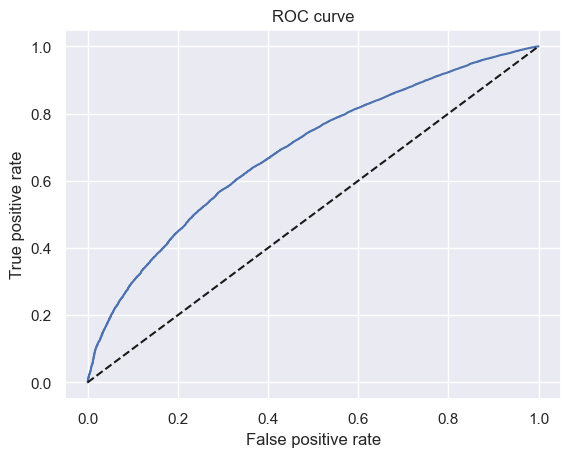

In [35]:
# Plotting the ROC curve herein
# false positive rate along the x-axis and the true positive rate along the y-axis,
plt.plot(fpr, tpr)
# Plotting a diagonal line, with dashed line style and black color.
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
# relabeling the axes
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [36]:
# Calculating AUROC from a set of actual values and their predicted probabilities.
AUROC = roc_auc_score(df_actual_predicted_probs['targets_test'],\
                      df_actual_predicted_probs['y_hat_test_proba'])
AUROC

0.6861062519108421

AUROC 0.69 is higher than 0.50 -> a better performance of random model

## Gini coefficient

In [37]:
#sorting proba values and resetting index
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()
# calculating cumulative pop, good and bad
df_actual_predicted_probs['Cum N Population'] = df_actual_predicted_probs.index + 1
df_actual_predicted_probs['Cum N Good'] = df_actual_predicted_probs['targets_test'].cumsum()
df_actual_predicted_probs['Cum N Bad'] = df_actual_predicted_probs['Cum N Population']\
                                        - df_actual_predicted_probs['Cum N Good']
# Calculating the cumulative percentage of all, good, and bad observations.
sum_all= df_actual_predicted_probs.shape[0]
df_actual_predicted_probs['Cum Perc Population'] = df_actual_predicted_probs['Cum N Population'] / sum_all
# Calculating cumulative percentage of 'good'.
sum_good=  df_actual_predicted_probs['targets_test'].sum()
df_actual_predicted_probs['Cum Perc Good'] = df_actual_predicted_probs['Cum N Good'] /sum_good
# Calculating the cumulative percentage of 'bad'.
sum_bad = sum_all- sum_good
df_actual_predicted_probs['Cum Perc Bad'] = df_actual_predicted_probs['Cum N Bad'] / sum_bad


In [38]:
df_actual_predicted_probs.tail()

,index,targets_test,y_hat_test_proba,y_hat_test,Cum N Population,Cum N Good,Cum N Bad,Cum Perc Population,Cum Perc Good,Cum Perc Bad
93252,262480,1,0.988487,1,93253,83063,10190,0.999957,0.999952,1.0
93253,416618,1,0.988634,1,93254,83064,10190,0.999968,0.999964,1.0
93254,460666,1,0.988828,1,93255,83065,10190,0.999979,0.999976,1.0
93255,332098,1,0.989021,1,93256,83066,10190,0.999989,0.999988,1.0
93256,312703,1,0.989556,1,93257,83067,10190,1.000000,1.000000,1.0


In [39]:
df_actual_predicted_probs.head()

,index,targets_test,y_hat_test_proba,y_hat_test,Cum N Population,Cum N Good,Cum N Bad,Cum Perc Population,Cum Perc Good,Cum Perc Bad
0,39810,0,0.398915,0,1,0,1,0.000011,0.000000,0.000098
1,40518,0,0.420621,0,2,0,2,0.000021,0.000000,0.000196
2,40173,0,0.447833,0,3,0,3,0.000032,0.000000,0.000294
3,41760,1,0.469404,0,4,1,3,0.000043,0.000012,0.000294
4,42344,1,0.473183,0,5,2,3,0.000054,0.000024,0.000294


Text(0.5, 1.0, 'Gini')

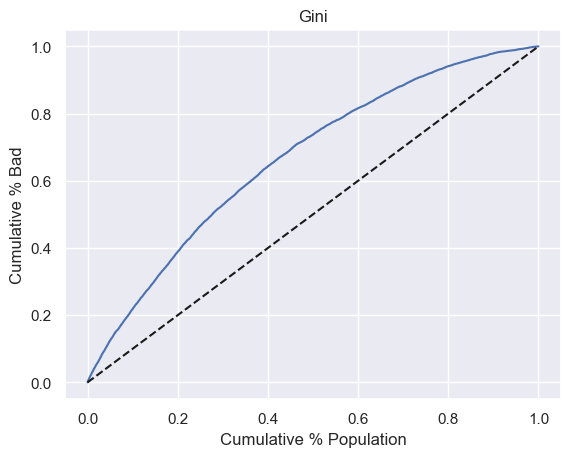

In [40]:
# Plotting Gini - cumulative percentage versus the cumulative percentage 'good' along the y-axis
plt.plot(df_actual_predicted_probs['Cum Perc Population'], df_actual_predicted_probs['Cum Perc Bad'])
# Plotting a seconary diagonal line, with dashed line style and black color.
plt.plot(df_actual_predicted_probs['Cum Perc Population'], df_actual_predicted_probs['Cum Perc Population'], linestyle = '--', color = 'k')
# Relabelling 
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini')

In [41]:
# Here we calculate Gini from AUROC.
Gini = AUROC * 2 - 1
Gini

0.37221250382168414

The Gini coefficient is a ratio showing that

*  how close our model to be a “perfect model" (a Gini coef of 1)
*  how far our model to be from being a “random model” (a Gini coefficient of 0)

The GINI score of 0.37 shows that there is still room for improvedment in building the PD model. (Perhaps: use SMOTE to address imbalanced data issues).  For this example, we keep the model as it is. 

## Kolmogorov-Smirnov coefficient

Text(0.5, 1.0, 'Kolmogorov-Smirnov')

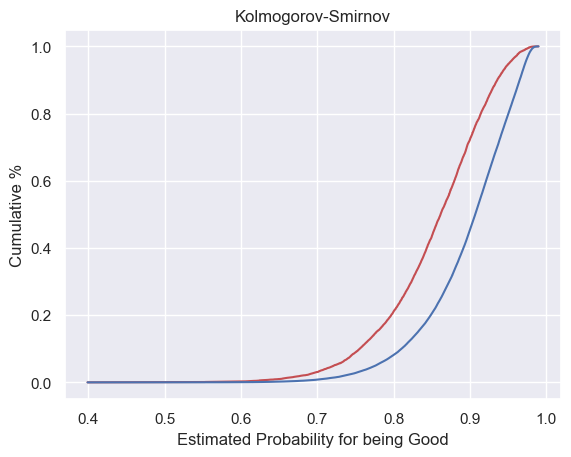

In [42]:
# Plotting KS 
# 1 predicted (estimated) probabilities versus the cumulative percentage 'bad' along the y-axis,
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cum Perc Bad'], color = 'r')
# 2 predicted (estimated) probabilities versus the cumulative percentage 'good' along the y-axis,
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cum Perc Good'], color = 'b')
# relabelling
plt.xlabel('Estimated Probability for being Good')
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov')

In [43]:
# Calculating KS from the data. 
# Max difference between the cumulative percentage of 'bad' and 'good'
KS = max(df_actual_predicted_probs['Cum Perc Bad'] - df_actual_predicted_probs['Cum Perc Good'])
KS

0.27527628624932193

# III. Decision making with PD model
## Creating a scorecard

In [44]:
df_ref_categories = pd.DataFrame(ref_categories,columns = ['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan

df_scorecard = pd.concat ([summary_table, df_ref_categories ])
df_scorecard = df_scorecard.reset_index()

df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]
df_scorecard.head()

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-0.814514,NaN,Intercept
1,1,grade:A,0.439412,4.198075e-07,grade
2,2,grade:B,0.552751,1.464341e-21,grade
3,3,grade:C,0.508389,8.406967e-21,grade
4,4,grade:D,0.438398,4.021486e-17,grade


In [46]:
#fix minimum score of 300 and max score of 850
min_score = 300
max_score = 850

In [48]:
#determining the ratio to multiply with the coefficients so that 
# min_score is equal to 300 and max_score is equal to 850
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
ratio_ = (max_score-min_score) / (max_sum_coef - min_sum_coef)
#calculating scores from coefs
df_scorecard.loc[:,'Score - Calculation'] = df_scorecard.loc[:,'Coefficients'] * ratio_
#replacing intercept coef
df_scorecard.loc[0,'Score - Calculation'] = (df_scorecard.loc[0,'Coefficients'] - min_sum_coef)*ratio_+ min_score
#rounding the scores to integer like
df_scorecard.loc[:,'Score - Preliminary'] = df_scorecard.loc[:,'Score - Calculation'].round()
df_scorecard.head()

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary
0,0,Intercept,-0.814514,NaN,Intercept,329.921225,330.0
1,1,grade:A,0.439412,4.198075e-07,grade,35.389717,35.0
2,2,grade:B,0.552751,1.464341e-21,grade,44.517900,45.0
3,3,grade:C,0.508389,8.406967e-21,grade,40.945034,41.0
4,4,grade:D,0.438398,4.021486e-17,grade,35.308076,35.0


In [49]:
#check if we have min score of 300 and max score of 850
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
#check if we have min score of 300 and max score of 850
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()
print(min_sum_score_prel, max_sum_score_prel)

300.0 850.0


In [106]:
# I.e : if max score is 849, we need to alter and increase one of the scores by 1 pt. Then, the values are rounded.
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
#let's check which index value to increase
df_scorecard['Difference'] =  df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']
#let's print out the max scores of each feature
df_scorecard.loc[df_scorecard.groupby(['Original feature name'])['Score - Final'].idxmax()]

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Score - Final,Difference
0,0,Intercept,-0.814514,NaN,Intercept,329.921225,330.0,330.0,0.078775
44,44,acc_now_delinq:>=1,0.161133,8.202582e-02,acc_now_delinq,12.977482,13.0,13.0,0.022518
21,21,addr_state:WV_NH_WY_DC_ME_ID,0.511206,4.755606e-22,addr_state,41.171949,41.0,41.0,-0.171949
61,61,annual_inc:120K-140K,0.537967,2.635653e-25,annual_inc,43.327226,43.0,43.0,-0.327226
65,65,dti:3.5-7.7,-0.000915,9.875640e-01,dti,-0.073677,-0.0,-0.0,0.073677
34,34,emp_length:10,0.118887,7.612872e-11,emp_length,9.575049,10.0,10.0,0.424951
2,2,grade:B,0.552751,1.464341e-21,grade,44.517900,45.0,45.0,0.482100
7,7,home_ownership:OWN,0.124618,4.754588e-10,home_ownership,10.036614,10.0,10.0,-0.036614
28,28,initial_list_status:w,0.290605,6.298864e-129,initial_list_status,23.405023,23.0,23.0,-0.405023
39,39,inq_last_6mths:0,1.111689,5.813347e-54,inq_last_6mths,89.534132,90.0,90.0,0.465868


In [ ]:
# #increasing the rounded score of some features 1+ to have max score of 850 at the end
# df_scorecard['Score - Final'][21]  = 39 #coef will be adjusted one pt higher

In [107]:
#let's check if we have min score of 300 and max score of 800
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].min().sum()
min_sum_score_prel

300.0

In [108]:
#let's check if we have min score of 300 and max score of 800
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].max().sum()
max_sum_score_prel

850.0

In [109]:
# export
inputs_test_ref_categories.to_csv('inputs_train_with_ref_categories.csv')

# inputs_test_ref_categories.to_csv('../data/inputs_train_with_ref_categories.csv')

In [110]:
# df_scorecard.to_csv('../data/df_scorecard.csv')

df_scorecard.to_csv('df_scorecard.csv')

### Calculating Credit Scores

In [111]:
inputs_test_ref_categories.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,annual_inc:>140K,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35
362514,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
288564,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
213591,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
263083,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
165001,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [112]:
# test dataset with reference categories
inputs_test_with_ref_cat_w_intercept = inputs_train.loc[: , features]
# inserting the intercept point w an index of 0, that is, in the beginning of df
# The name of that column is 'Intercept', and its values are 1s.
inputs_test_with_ref_cat_w_intercept.insert(0,'Intercept', 1)
# ensuring that we selected the same features used in scorecard 
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept [df_scorecard['Feature name'].values]

inputs_test_with_ref_cat_w_intercept.shape

(373028, 87)

In [113]:
#creating the score card array
scorecard_scores = df_scorecard['Score - Final']
scorecard_scores.shape

(87,)

In [114]:
#from list to an array
scorecard_scores = scorecard_scores.values.reshape(87,1)
# multiplying the values of each row of the dataframe by the values of each column of the variable,
# with 'dot' method (sum of the products)
y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)

In [115]:
y_scores.head()

,0
427211,665.0
206088,592.0
136020,657.0
412305,491.0
36159,527.0


### From Credit Score to PD



In [116]:
# Dividing the difference b/w the scores and the minimum score by diff b/w max and min score.
# Multiplying by the diff b/w max sum of coefs and min sum of coefs.
# Adding minimum sum of coefs.
coef_ =   (max_sum_coef - min_sum_coef) / (max_score - min_score) 
sum_coef_from_score = (y_scores - min_score) * coef_ + min_sum_coef
# dividing an exponent raised to sum of coefs from score by
# an exponent raised to sum of coefs from score plus one.
y_hat_proba_from_score = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)
y_hat_proba_from_score.head()

,0
427211,0.965972
206088,0.919794
136020,0.962551
412305,0.765935
36159,0.836510


# IV. Set Cut-offs

In [117]:
# Getting ROC Curve and their predicted probabilities.
# It returns us the false positive rates, the true positive rates, and the thresholds.
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['targets_test'],\
          df_actual_predicted_probs['y_hat_test_proba'])
# Conconating 3 dataframes along the columns.
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis = 1)
# Naming the columns of the dataframe 'thresholds', 'fpr', and 'tpr'.
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']

In [118]:
# Let the 1st threshold (the value of the thresholds column with index 0) be equal 
# very close to 1 but smaller than 1
df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 20)

# The score corresponding to each threshold equals:
ratio_ = (max_score-min_score) / (max_sum_coef - min_sum_coef)
df_cutoffs['Score'] = ((np.log(df_cutoffs['thresholds'] / (1 - df_cutoffs['thresholds'])) - min_sum_coef) * ratio_ + min_score).round()
df_cutoffs['Score'][0] = max_score

In [119]:
# defining a function called 'n_approved' which assigns a value of 1 if a predicted probability
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba'] >= p, 1, 0).sum()

# With the assumption that a given probability of being 'good' will be approved,
# we obtain # of approved applications.
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)

# Calculating # of rejected applications for each threshold.
df_cutoffs['N Rejected'] = df_actual_predicted_probs['y_hat_test_proba'].shape[0] - df_cutoffs['N Approved']

# Approval rate = the ratio of the apprv'd apps and all apps.
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_predicted_probs['y_hat_test_proba'].shape[0]

# Rejection rate.
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']

In [120]:
# displaying the df with cutoffs 
df_cutoffs.iloc[5600: 5650, ]

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
5600,0.903196,0.257409,0.524444,575.0,46187,47070,0.495266,0.504734
5601,0.903193,0.257507,0.524444,575.0,46188,47069,0.495276,0.504724
5602,0.903182,0.257507,0.524552,575.0,46197,47060,0.495373,0.504627
5603,0.903180,0.257605,0.524552,575.0,46198,47059,0.495384,0.504616
5604,0.903174,0.257605,0.524589,575.0,46201,47056,0.495416,0.504584
5605,0.903174,0.257704,0.524589,575.0,46202,47055,0.495427,0.504573
5606,0.903160,0.257704,0.524733,575.0,46214,47043,0.495555,0.504445
5607,0.903159,0.257802,0.524733,575.0,46215,47042,0.495566,0.504434
5608,0.903155,0.257802,0.524769,575.0,46218,47039,0.495598,0.504402
5609,0.903151,0.257900,0.524769,575.0,46219,47038,0.495609,0.504391


If the cutoff is 575, about half of the loan applications will be accepted 

In [121]:
df_cutoffs.iloc[1000: 2000, ]
# Here we display the dataframe with cutoffs form line with index 1000 to line with index 2000.

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
1000,0.955814,0.038665,0.162158,643.0,13864,79393,0.148664,0.851336
1001,0.955720,0.038665,0.162808,643.0,13918,79339,0.149243,0.850757
1002,0.955716,0.038763,0.162808,643.0,13919,79338,0.149254,0.850746
1003,0.955690,0.038763,0.162881,643.0,13925,79332,0.149319,0.850681
1004,0.955689,0.038862,0.162881,643.0,13926,79331,0.149329,0.850671
...,...,...,...,...,...,...,...,...
1995,0.940028,0.084102,0.268241,617.0,23139,70118,0.248121,0.751879
1996,0.939999,0.084102,0.268494,617.0,23160,70097,0.248346,0.751654
1997,0.939999,0.084200,0.268494,617.0,23161,70096,0.248357,0.751643
1998,0.939996,0.084200,0.268578,617.0,23168,70089,0.248432,0.751568


If the cutoff is 643, only about 15% of the loan applications will be accepted 